# Data Exploration and Audit

**Project**: BYU IS 455 — Northstar Shelters ML Workspace  
**Purpose**: shared exploratory analysis across all INTEX ML pipelines

---

This notebook is the shared EDA companion for the scored ML pipelines. It documents the dataset inventory, data quality checks, and the reusable snapshot tables that power the donor, resident, safehouse, and outreach models.


## Goals

- verify the full dataset loads correctly
- summarize table sizes, date ranges, and missingness
- inspect cross-domain structure at a high level
- build example snapshot tables from the shared loader utilities
- establish one place in the repo where the overall data story is documented


In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from shared.config import ALL_TABLES, DATA_DIR
from shared.data_loader import (
    load_all,
    build_donor_snapshot,
    build_resident_snapshot,
    build_safehouse_monthly,
    build_session_features,
    build_visitation_features,
)

sns.set_palette('tab10')
plt.rcParams['figure.figsize'] = (12, 5)

print('Data directory:', DATA_DIR)
print('Expected tables:', len(ALL_TABLES))


Data directory: C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\455-Things\lighthouse_csv_v7\lighthouse_csv_v7
Expected tables: 17


In [2]:
tables = load_all()

summary_rows = []
for name, df in sorted(tables.items()):
    summary_rows.append({
        'table': name,
        'rows': len(df),
        'cols': len(df.columns),
        'missing_cells': int(df.isna().sum().sum()),
        'duplicate_rows': int(df.duplicated().sum()),
    })

summary_df = pd.DataFrame(summary_rows).sort_values('rows', ascending=False)
print(summary_df.to_string(index=False))


[load_all] Loaded 17 tables: ['donation_allocations', 'donations', 'education_records', 'health_wellbeing_records', 'home_visitations', 'in_kind_donation_items', 'incident_reports', 'intervention_plans', 'partner_assignments', 'partners', 'process_recordings', 'public_impact_snapshots', 'residents', 'safehouse_monthly_metrics', 'safehouses', 'social_media_posts', 'supporters']


                    table  rows  cols  missing_cells  duplicate_rows
       process_recordings  2819    15           2819               0
         home_visitations  1337    14            974               0
       social_media_posts   812    39           5153               0
 health_wellbeing_records   534    14              0               0
        education_records   534    10              0               0
     donation_allocations   521     7            521               0
safehouse_monthly_metrics   450    11            844               0
                donations   420    13            990               0
       intervention_plans   180    11             48               0
   in_kind_donation_items   129     9              0               0
         incident_reports   100    12             29               0
               supporters    60    15             65               0
                residents    60    49            278               0
  public_impact_snapshots    50   

In [3]:
date_summary = []
for name, df in sorted(tables.items()):
    for col in df.columns:
        if 'date' in col.lower() or col.lower().endswith('_at'):
            parsed = pd.to_datetime(df[col], errors='coerce')
            if parsed.notna().sum() > 0:
                date_summary.append({
                    'table': name,
                    'date_col': col,
                    'non_null_dates': int(parsed.notna().sum()),
                    'min_date': parsed.min(),
                    'max_date': parsed.max(),
                })

date_df = pd.DataFrame(date_summary).sort_values(['table', 'date_col'])
print(date_df.to_string(index=False))


                   table                 date_col  non_null_dates            min_date            max_date
    donation_allocations          allocation_date             521 2023-01-09 00:00:00 2026-03-01 00:00:00
               donations            donation_date             420 2023-01-09 00:00:00 2026-03-01 00:00:00
       education_records              record_date             534 2023-01-01 00:00:00 2026-02-01 00:00:00
health_wellbeing_records              record_date             534 2023-01-01 00:00:00 2026-02-01 00:00:00
        home_visitations               visit_date            1337 2023-02-23 00:00:00 2027-01-23 00:00:00
        incident_reports            incident_date             100 2023-04-08 00:00:00 2026-04-09 00:00:00
        incident_reports          resolution_date              71 2023-10-04 00:00:00 2026-04-17 00:00:00
      intervention_plans     case_conference_date             132 2023-01-15 00:00:00 2025-11-07 00:00:00
      intervention_plans               created

In [4]:
null_rows = []
for name, df in sorted(tables.items()):
    top_nulls = df.isna().sum().sort_values(ascending=False).head(5)
    for col, cnt in top_nulls.items():
        null_rows.append({
            'table': name,
            'column': col,
            'null_count': int(cnt),
            'null_pct': round(float(cnt / len(df)) if len(df) else 0.0, 4),
        })

null_df = pd.DataFrame(null_rows)
print(null_df.to_string(index=False))


                    table                    column  null_count  null_pct
     donation_allocations          allocation_notes         521    1.0000
     donation_allocations               donation_id           0    0.0000
     donation_allocations             allocation_id           0    0.0000
     donation_allocations              safehouse_id           0    0.0000
     donation_allocations              program_area           0    0.0000
                donations          referral_post_id         343    0.8167
                donations             campaign_name         275    0.6548
                donations                    amount         186    0.4429
                donations             currency_code         186    0.4429
                donations               donation_id           0    0.0000
        education_records       education_record_id           0    0.0000
        education_records               resident_id           0    0.0000
        education_records             

## Snapshot Builders

The shared ML utilities define reusable snapshot logic. These builders are important because they enforce the leakage rules used across multiple pipelines:

- features come from data on or before the snapshot date
- labels come strictly after the snapshot date
- the same builder can be reused across notebooks and later backend jobs


In [5]:
donor_snap = build_donor_snapshot(tables, pd.Timestamp('2024-12-01'), outcome_window_days=90)
print('Donor snapshot shape:', donor_snap.shape)
display_cols = [
    'supporter_id', 'supporter_type', 'region', 'recency_days',
    'frequency', 'monetary_total', 'allocation_spread', 'label_donated_again'
]
display(donor_snap[display_cols].head(10))


[donor_snapshot] 60 supporters | label=1: 24 (40.0%)
Donor snapshot shape: (60, 24)


,supporter_id,supporter_type,region,recency_days,frequency,monetary_total,allocation_spread,label_donated_again
0,1,SocialMediaAdvocate,Luzon,45.0,8.0,6501.15,0.0,1
1,2,Volunteer,Mindanao,433.0,3.0,3480.08,NaN,0
2,3,MonetaryDonor,Luzon,13.0,10.0,4444.28,NaN,1
3,4,MonetaryDonor,Mindanao,48.0,7.0,4693.27,NaN,0
4,5,InKindDonor,Mindanao,318.0,2.0,2022.07,NaN,1
5,6,MonetaryDonor,Visayas,116.0,4.0,3595.64,NaN,1
6,7,MonetaryDonor,Mindanao,2.0,5.0,469.97,NaN,1
7,8,InKindDonor,Mindanao,7.0,9.0,5438.54,NaN,1
8,9,Volunteer,Luzon,23.0,6.0,6800.82,NaN,0
9,10,Volunteer,Luzon,44.0,3.0,0.00,NaN,1


In [6]:
resident_snap = build_resident_snapshot(tables, pd.Timestamp('2025-07-01'), outcome_window_days=30)
print('Resident snapshot shape:', resident_snap.shape)
display_cols = [
    'resident_id', 'days_since_last_visitation', 'incident_count_30d',
    'incident_count_90d', 'intervention_recency_days', 'label_incident'
]
display(resident_snap[display_cols].head(10))


[resident_snapshot] 60 residents | label=1: 5
Resident snapshot shape: (60, 8)


,resident_id,days_since_last_visitation,incident_count_30d,incident_count_90d,intervention_recency_days,label_incident
0,1,44.0,0.0,1.0,516.0,0
1,2,179.0,0.0,0.0,608.0,0
2,3,74.0,0.0,1.0,150.0,0
3,4,8.0,0.0,0.0,30.0,1
4,5,279.0,0.0,0.0,334.0,0
5,6,7.0,0.0,0.0,426.0,0
6,7,18.0,0.0,0.0,181.0,0
7,8,3.0,0.0,0.0,395.0,0
8,9,999.0,0.0,0.0,999.0,0
9,10,17.0,0.0,0.0,456.0,0


In [7]:
safehouse_panel = build_safehouse_monthly(tables)
print('Safehouse monthly shape:', safehouse_panel.shape)
display(
    safehouse_panel[
        ['safehouse_id', 'month_start', 'active_residents', 'active_residents_lag1', 'active_residents_lag2', 'active_residents_roll3']
    ].head(12)
)


[safehouse_monthly] 450 rows | 9 safehouses | target='active_residents'
Safehouse monthly shape: (450, 17)


,safehouse_id,month_start,active_residents,active_residents_lag1,active_residents_lag2,active_residents_roll3
0,1,2023-01-01,10,NaN,NaN,NaN
1,1,2023-02-01,10,10.0,NaN,10.0
2,1,2023-03-01,10,10.0,10.0,10.0
3,1,2023-04-01,10,10.0,10.0,10.0
4,1,2023-05-01,10,10.0,10.0,10.0
5,1,2023-06-01,10,10.0,10.0,10.0
6,1,2023-07-01,10,10.0,10.0,10.0
7,1,2023-08-01,10,10.0,10.0,10.0
8,1,2023-09-01,10,10.0,10.0,10.0
9,1,2023-10-01,10,10.0,10.0,10.0


In [8]:
session_features = build_session_features(tables)
visitation_features = build_visitation_features(tables)
print('Session-level rows:', session_features.shape)
print('Visitation-level rows:', visitation_features.shape)


[session_features] 2819 sessions | label=1: 677 (24.0%)
[visitation_features] 1337 visits | label=1: 551 (41.2%)
Session-level rows: (2819, 23)
Visitation-level rows: (1337, 22)


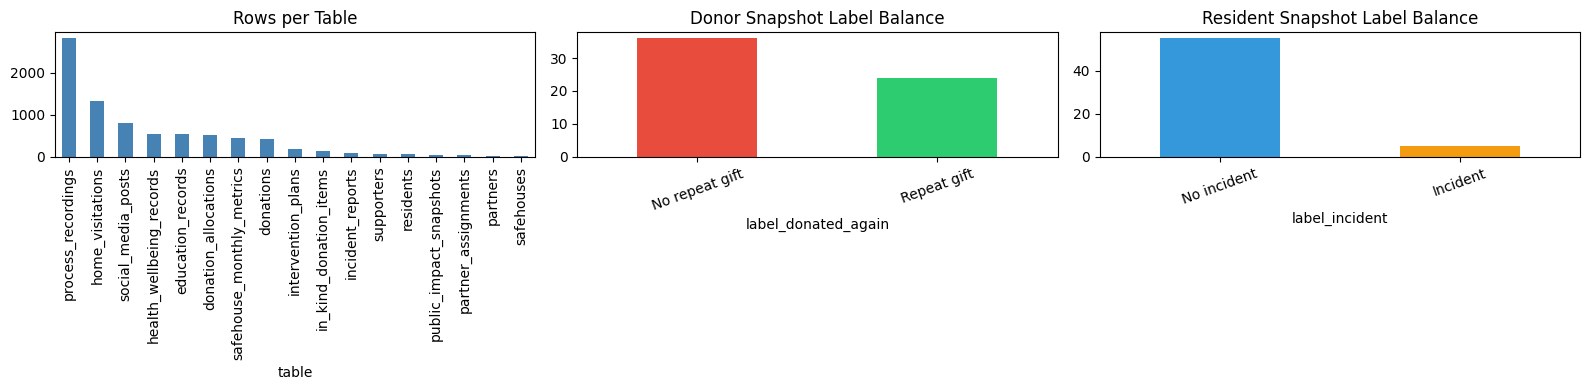

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

summary_df.plot.bar(x='table', y='rows', ax=axes[0], legend=False, color='steelblue')
axes[0].set_title('Rows per Table')
axes[0].tick_params(axis='x', rotation=90)

donor_snap['label_donated_again'].value_counts().sort_index().plot.bar(ax=axes[1], color=['#e74c3c', '#2ecc71'])
axes[1].set_title('Donor Snapshot Label Balance')
axes[1].set_xticklabels(['No repeat gift', 'Repeat gift'], rotation=20)

resident_snap['label_incident'].value_counts().sort_index().plot.bar(ax=axes[2], color=['#3498db', '#f39c12'])
axes[2].set_title('Resident Snapshot Label Balance')
axes[2].set_xticklabels(['No incident', 'Incident'], rotation=20)

plt.tight_layout()
plt.show()


## Findings

- The full dataset loads cleanly through the shared loader utilities
- The three major modeling domains are all represented: donor/support, case management, and outreach
- The shared snapshot builders are a strong foundation for reproducible ML work
- Missingness is concentrated in expected optional fields rather than core IDs or timestamps
- The case-management and outreach tables are rich enough to support multiple defensible predictive problems
